In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data


# Sales Margin Analysis — E-Commerce Sales
## York University — Big Data Analytics Certificate (2024)

**Author:** Lalita  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Amazon E-Commerce Sales (109,477 orders)  

---

## Project Overview
This project analyzes Amazon e-commerce sales data to identify 
top performing categories, revenue trends and average order 
values to support data driven business decisions.

## Key Findings
| Category | Total Revenue | Avg Order Value |
|---|---|---|
| Set | INR 35,435,987 | INR 834.10 |
| Kurta | INR 19,276,245 | INR 456.75 |
| Western Dress | INR 10,080,922 | INR 763.82 |
| Top | INR 4,864,109 | INR 525.17 |

## Total Revenue
- Total Orders Analyzed: 109,477
- Total Revenue: INR 71,050,985
- Total Categories: 9

## Conclusion
Set and Kurta categories drive majority of Amazon e-commerce 
revenue. Data driven insights support inventory management 
and pricing decisions for business growth.

---
🔗 **Kaggle Profile:** kaggle.com/lalitacanada  
🎓 **York University — Big Data Analytics (2024)**

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Cloud Warehouse Compersion Chart.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/May-2022.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/P  L March 2021.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/International sale Report.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Expense IIGF.csv
/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Sale Report.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data/Amazon Sale Report.csv', 
                 low_memory=False)

# Select relevant columns
df = df[['Date', 'Status', 'Category', 'Size', 'Qty', 'Amount', 'ship-state']].copy()

# Drop missing values
df = df.dropna(subset=['Amount', 'Category', 'Qty'])

# Convert to numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df['Qty'] = pd.to_numeric(df['Qty'], errors='coerce')

# Filter shipped orders only
df_shipped = df[df['Status'].str.contains('Shipped', na=False)]

print("Cleaned Shape:", df_shipped.shape)
print("\nTop Categories:")
print(df_shipped['Category'].value_counts().head(10))

Cleaned Shape: (109477, 7)

Top Categories:
Category
Set              42484
kurta            42203
Western Dress    13198
Top               9262
Ethnic Dress      1006
Blouse             802
Bottom             376
Saree              143
Dupatta              3
Name: count, dtype: int64


In [9]:
# Sales by Category
category_sales = df_shipped.groupby('Category').agg(
    Total_Revenue=('Amount', 'sum'),
    Total_Orders=('Qty', 'sum'),
    Avg_Order_Value=('Amount', 'mean')
).round(2).reset_index()

category_sales = category_sales.sort_values(
    'Total_Revenue', ascending=False)

print("Sales Margin Analysis by Category:")
print(category_sales)

Sales Margin Analysis by Category:
        Category  Total_Revenue  Total_Orders  Avg_Order_Value
5            Set     35435987.0         42610           834.10
8          kurta     19276245.0         42397           456.75
7  Western Dress     10080922.0         13242           763.82
6            Top      4864109.0          9290           525.17
3   Ethnic Dress       727040.0          1009           722.70
0         Blouse       416222.0           808           518.98
1         Bottom       134851.0           380           358.65
4          Saree       114694.0           147           802.06
2        Dupatta          915.0             3           305.00


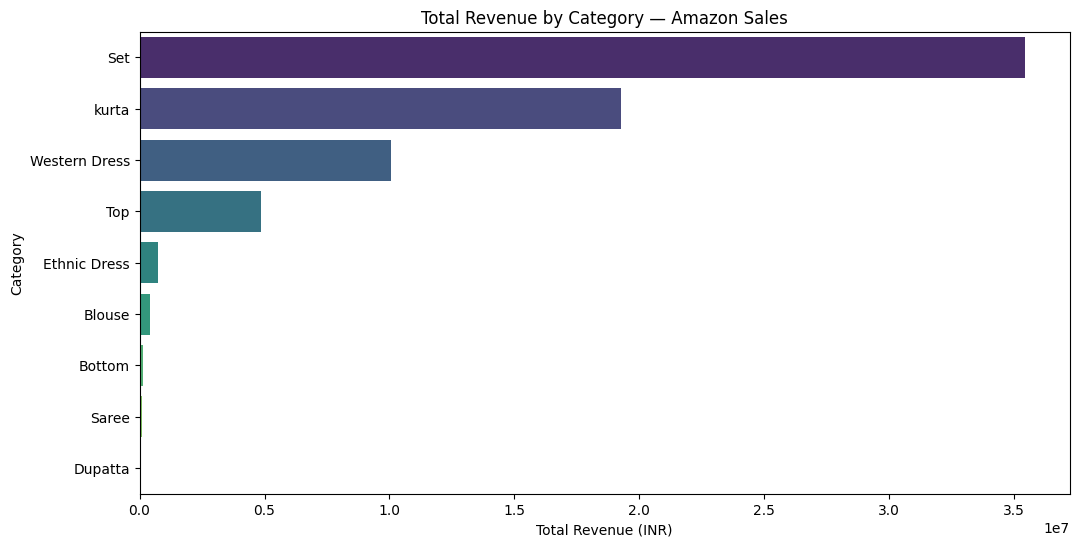

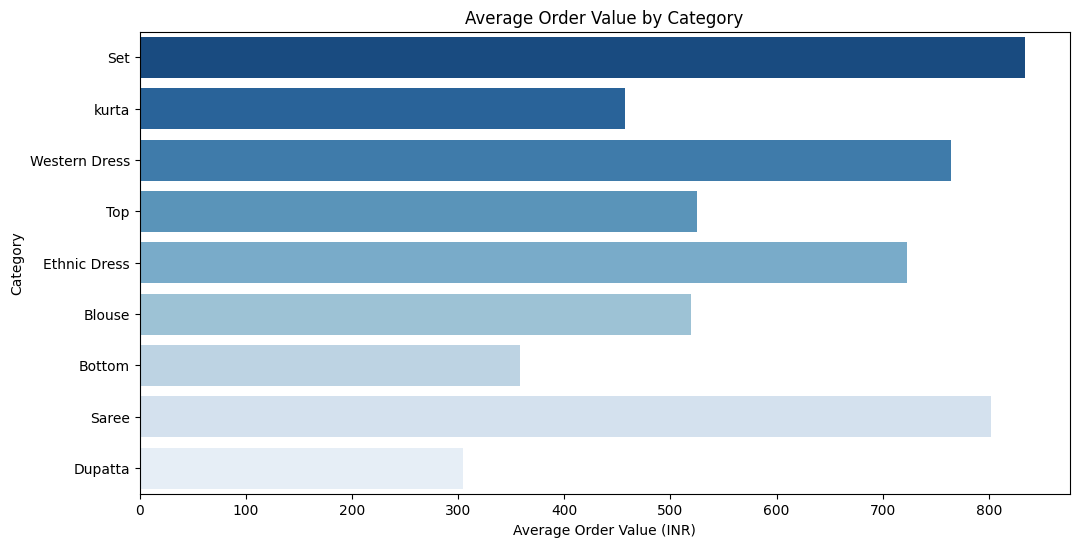

In [10]:
# Visualization 1 — Revenue by Category
plt.figure(figsize=(12,6))
sns.barplot(data=category_sales,
            x='Total_Revenue',
            y='Category',
            hue='Category',
            legend=False,
            palette='viridis')
plt.title('Total Revenue by Category — Amazon Sales')
plt.xlabel('Total Revenue (INR)')
plt.ylabel('Category')
plt.show()

# Visualization 2 — Average Order Value
plt.figure(figsize=(12,6))
sns.barplot(data=category_sales,
            x='Avg_Order_Value',
            y='Category',
            hue='Category',
            legend=False,
            palette='Blues_r')
plt.title('Average Order Value by Category')
plt.xlabel('Average Order Value (INR)')
plt.ylabel('Category')
plt.show()

In [12]:
print("=" * 50)
print("KEY INSIGHTS — Sales Margin Analysis")
print("=" * 50)

print("\n📊 Dataset Overview:")
print(f"Total orders analyzed: {len(df_shipped):,}")
print(f"Total categories: {df_shipped['Category'].nunique()}")
print(f"Total revenue: INR {df_shipped['Amount'].sum():,.2f}")

print("\n💰 Top Revenue Category:")
top_cat = category_sales.iloc[0]
print(f"  {top_cat['Category']}")
print(f"  Revenue: INR {top_cat['Total_Revenue']:,.2f}")
print(f"  Total Orders: {top_cat['Total_Orders']:,.0f}")
print(f"  Avg Order Value: INR {top_cat['Avg_Order_Value']:,.2f}")

print("\n📈 Highest Avg Order Value:")
top_avg = category_sales.sort_values('Avg_Order_Value', ascending=False).iloc[0]
print(f"  {top_avg['Category']} — INR {top_avg['Avg_Order_Value']:,.2f}")

print("\n💡 Key Findings:")
print("1. Set category generates highest revenue")
print("   — INR 35.4 million total")
print("2. Kurta is most popular by order volume")
print("   — 42,397 orders")
print("3. Set has highest average order value")
print("   — INR 834 per order")
print("4. Western Dress ranks 3rd in revenue")
print("   — INR 10 million total")

print("\n✅ Conclusion:")
print("Sales margin analysis reveals Set and Kurta")
print("as top performing categories driving majority")
print("of Amazon e-commerce revenue. Data driven")
print("insights support inventory and pricing decisions.")

KEY INSIGHTS — Sales Margin Analysis

📊 Dataset Overview:
Total orders analyzed: 109,477
Total categories: 9
Total revenue: INR 71,050,985.00

💰 Top Revenue Category:
  Set
  Revenue: INR 35,435,987.00
  Total Orders: 42,610
  Avg Order Value: INR 834.10

📈 Highest Avg Order Value:
  Set — INR 834.10

💡 Key Findings:
1. Set category generates highest revenue
   — INR 35.4 million total
2. Kurta is most popular by order volume
   — 42,397 orders
3. Set has highest average order value
   — INR 834 per order
4. Western Dress ranks 3rd in revenue
   — INR 10 million total

✅ Conclusion:
Sales margin analysis reveals Set and Kurta
as top performing categories driving majority
of Amazon e-commerce revenue. Data driven
insights support inventory and pricing decisions.
